In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive

In [ ]:
b=pd.read_csv("/social_media_engagement_5000.csv")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [ ]:
from collections import Counter
import re

In [ ]:
plt.rcParams["figure.figsize"]=(10,6)
sns.set_theme(style="whitegrid")
print("Libraries and dataset imported successfully")

Libraries and dataset imported successfully


In [ ]:
print("Number of rows:",b.shape[0])
print("Number of columns:",b.shape[1])
b.head()

Number of rows: 5000
Number of columns: 19


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,1970-01-01 00:00:00.000005726,44650,17-12-2022,81734,False,mobile,NaT,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,1970-01-01 00:00:00.000005947,80216,02-06-2023,5963,False,mobile,NaT,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,1970-01-01 00:00:00.000006946,44858,07-05-2023,501783,False,tablet,NaT,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,1970-01-01 00:00:00.000000229,70455,12-02-2023,480212,False,mobile,NaT,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,1970-01-01 00:00:00.000004798,6019,23-05-2023,383936,False,mobile,NaT,#travel,2.777372


In [ ]:
b.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,1970-01-01 00:00:00.000006190,42977,25-06-2022,646147,False,mobile,NaT,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,1970-01-01 00:00:00.000007764,34196,18-11-2022,584603,False,desktop,NaT,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,1970-01-01 00:00:00.000007466,23680,06-04-2023,483550,False,desktop,NaT,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,1970-01-01 00:00:00.000004991,89013,16-05-2022,183295,False,tablet,NaT,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,1970-01-01 00:00:00.000003743,14234,04-03-2023,585760,False,desktop,NaT,#foodie #lifestyle #fashion,1.203527


In [ ]:
b.columns.tolist()

['user_id',
 'age',
 'gender',
 'country',
 'post_id',
 'post_type',
 'post_category',
 'likes',
 'comments',
 'shares',
 'watch_time_sec',
 'impression_count',
 'posted_at',
 'follower_count',
 'is_verified',
 'device_type',
 'sentiment',
 'hashtags',
 'engagement_rate']

In [ ]:
# Check initial info
b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
date_cols = [col for col in b.columns if 'date' in col.lower() or 'time' in col.lower()]
for col in date_cols:
  b[col] = pd.to_datetime(b[col],errors='coerce')

/tmp/ipykernel_3449/2383828286.py:3: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [ ]:
#Total missing values
missing_values = b.isnull().sum()

In [ ]:
print("Missing values in each column:")
display(missing_values[missing_values > 0])


Missing values in each column:


,0
age,150
gender,150
likes,150
comments,150
shares,150
sentiment,150


In [ ]:
#Missing value percentage
missing_percentage = (
    b.isnull().sum() / len(b) * 100
).sort_values(ascending=False)

display(
    missing_percentage[missing_percentage > 0]
)


,0
age,3.0
gender,3.0
comments,3.0
likes,3.0
shares,3.0
sentiment,3.0


In [ ]:
#Filling numerical column with median
numeric_columns = b.select_dtypes(include=np.number).columns

for col in numeric_columns:
    b[col] = b[col].fillna(b[col].median())


In [ ]:
#fill catogorical column by mode
categorical_columns = b.select_dtypes(include="object").columns

for col in categorical_columns:
    if b[col].isnull().sum() > 0:
        b[col] = b[col].fillna(b[col].mode()[0])


In [ ]:
print("Remaining missing values:")
print(b.isnull().sum().sum())


Remaining missing values:
0


In [ ]:
#Remove duplicate records
print("Number of duplicate rows:", b.duplicated().sum())

b = b.drop_duplicates()

print("Dataset shape after removing duplicates:")
print(b.shape)



Number of duplicate rows: 0
Dataset shape after removing duplicates:
(5000, 19)


In [ ]:
#standardizing numerical data
# Standardize object columns
for col in b.select_dtypes(include="object").columns:
    b[col] = (
        b[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )


In [ ]:
if "sentiment" in b.columns:
    b["sentiment"] = (
        b["sentiment"]
        .astype(str)
        .str.strip()
        .str.lower()
    )
print(b["sentiment"].value_counts())

sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64


In [ ]:
#check un realistic value
engagement_columns = [
    "likes",
    "comments",
    "shares"
]

for col in engagement_columns:
    if col in b.columns:
        print(f"\n{col}")
        print("Minimum:", b[col].min())
        print("Maximum:", b[col].max())
        print("Negative values:", (b[col] < 0).sum())




likes
Minimum: 10.0
Maximum: 19998.0
Negative values: 0

comments
Minimum: 0.0
Maximum: 2999.0
Negative values: 0

shares
Minimum: 0.0
Maximum: 1999.0
Negative values: 0


In [ ]:
#fill negative engagement value
for col in engagement_columns:
    if col in b.columns:
        b.loc[b[col] < 0, col] = np.nan
        b[col] = b[col].fillna(b[col].median())


In [ ]:
#extract hashtag count
def count_hashtags(text):
    if pd.isna(text):
        return 0

    return len(re.findall(r"#\w+", str(text)))


In [ ]:
# Try common caption/text columns
text_columns = ["caption", "text", "content", "post_text"]

for col in text_columns:
    if col in b.columns:
        b["hashtag_count"] = b[col].apply(count_hashtags)
        print(f"Hashtag count created using: {col}")
        break


In [ ]:
#Numpy operations
# Example using likes
if "likes" in b.columns:

    likes_array = np.array(b["likes"])

    print("Likes Array:")
    print(likes_array[:10])

    print("Mean:", np.mean(likes_array))
    print("Maximum:", np.max(likes_array))
    print("Minimum:", np.min(likes_array))
    print("Standard Deviation:", np.std(likes_array))

Likes Array:
[ 7011.  11750.   4862.   5350.  12682.  12535.  11703.   9611.  10105.5
 14106. ]
Mean: 10106.9974
Maximum: 19998.0
Minimum: 10.0
Standard Deviation: 5701.722759367843


In [ ]:
# dataset summary statistics
b. describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,393698.224800,0.964356
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,230927.884535,5.318029
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,799533.000000,191.504348


In [ ]:
#catogorical analysis
for col in b.select_dtypes(include="object").columns:
    print("\n==============================")
    print("Column:", col)
    print("Unique values:", b[col].nunique())
    print(b[col].value_counts().head(10))




Column: gender
Unique values: 3
gender
male      1849
other     1581
female    1570
Name: count, dtype: int64

Column: country
Unique values: 10
country
india        535
canada       513
brazil       504
uae          503
usa          501
france       496
uk           493
australia    493
germany      490
japan        472
Name: count, dtype: int64

Column: post_type
Unique values: 4
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

Column: post_category
Unique values: 8
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64

Column: posted_at
Unique values: 729
posted_at
26-12-2023    16
28-06-2023    16
05-08-2022    16
26-11-2023    15
17-08-2022    15
12-04-2022    15
01-06-2023    14
07-06-2023    14
15-08-2022    13
30-01-2023    13
Name: count, dtype: int64

Column: device_type
Unique values: 3
device_type
mobile     1

In [ ]:
#Creating Engagement score fileld
required_columns = ["likes", "comments", "shares"]

if all(col in b.columns for col in required_columns):

    b["engagement_score"] = (
        b["likes"]
        + b["comments"]
        + b["shares"]
    )

    print(b[
        ["likes", "comments", "shares", "engagement_score"]
    ].head())

     likes  comments  shares  engagement_score
0   7011.0     354.0  1157.0            8522.0
1  11750.0    2606.0  1807.0           16163.0
2   4862.0     344.0   955.0            6161.0
3   5350.0    1083.0  1049.0            7482.0
4  12682.0    2735.0  1300.0           16717.0


In [ ]:
#Engagement rate
if "impressions" in b.columns:

    b["engagement_rate_calculated"] = (
        b["engagement_score"] /
        b["impressions"].replace(0, np.nan)
    ) * 100

    b["engagement_rate_calculated"] = (
        b["engagement_rate_calculated"].fillna(0)
    )

    b.head()


In [ ]:
#Group by analysis
if "post_type" in b.columns and "likes" in b.columns:

    avg_likes_post_type = (
        b.groupby("post_type")["likes"]
        .mean()
        .sort_values(ascending=False)
    )

    display(avg_likes_post_type)

,likes
post_type,
video,10188.600000
image,10104.865277
text,10100.148193
reel,10037.802416


In [ ]:
#Impressions by country
if "country" in b.columns and "impressions" in b.columns:

    country_impressions = (
        b.groupby("country")["impressions"]
        .sum()
        .sort_values(ascending=False)
    )

    display(country_impressions)


In [ ]:
#Impressions by country
if "country" in b.columns and "impressions" in b.columns:

    country_impressions = (
        b.groupby("country")["impressions"]
        .sum()
        .sort_values(ascending=False)
    )

    display(country_impressions)


In [ ]:
#Engagement by sentiment

if "sentiment" in b.columns:

    sentiment_engagement = (
        b.groupby("sentiment")["engagement_score"]
        .mean()
        .sort_values(ascending=False)
    )

    display(sentiment_engagement)



,engagement_score
sentiment,
negative,12731.498958
positive,12665.799443
neutral,12448.163720


In [ ]:
#Statisticsl Analysis


statistics_columns = [
    "likes",
    "comments",
    "shares",
    "watch_time",
    "engagement_rate",
    "followers"
]

available_statistics_columns = [
    col for col in statistics_columns
    if col in b.columns
]

statistics_summary = []

for col in available_statistics_columns:

    statistics_summary.append({
        "Metric": col,
        "Mean": b[col].mean(),
        "Median": b[col].median(),
        "Mode": b[col].mode().iloc[0],
        "Standard Deviation": b[col].std(),
        "Variance": b[col].var(),
        "25th Percentile": b[col].quantile(0.25),
        "50th Percentile": b[col].quantile(0.50),
        "75th Percentile": b[col].quantile(0.75),
        "Minimum": b[col].min(),
        "Maximum": b[col].max()
    })

statistics_df = pd.DataFrame(statistics_summary)

display(statistics_df)



,Metric,Mean,Median,Mode,Standard Deviation,Variance,25th Percentile,50th Percentile,75th Percentile,Minimum,Maximum
0,likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07,5235.000000,10105.500000,14959.000000,10.000000,19998.000000
1,comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,792.000000,1497.000000,2235.250000,0.000000,2999.000000
2,shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,511.000000,1012.000000,1483.000000,0.000000,1999.000000
3,engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.145781,0.253896,0.504794,0.006363,191.504348


In [ ]:
#Correlation Matrix
numeric_b = b.select_dtypes(include=np.number)

correlation_matrix = numeric_b.corr()

display(correlation_matrix)



,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,engagement_score
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,0.021868
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,-0.035531
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.012947
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,0.983942
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,0.130552
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.104285
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,0.007616
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,0.005937
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,-0.025467
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.094382


In [ ]:
#Visualisations
#Likes vs impressions
if "likes" in b.columns and "impressions" in b.columns:

    plt.figure(figsize=(10, 6))

    plt.scatter(
        b["impressions"],
        b["likes"],
        alpha=0.5
    )

    plt.xlabel("Impressions")
    plt.ylabel("Likes")
    plt.title("Likes vs Impressions")

    plt.show()

In [ ]:
#Visualization 2 — Daily Engagement Trend

date_column = None

for col in ["date", "Date", "post_date", "Post_Date", "created_at"]:
    if col in b.columns:
        date_column = col
        break

if date_column and "engagement_score" in b.columns:

    daily_engagement = (
        b.groupby(date_column)["engagement_score"]
        .sum()
    )

    plt.figure(figsize=(12, 6))

    daily_engagement.plot()

    plt.xlabel("Date")
    plt.ylabel("Engagement Score")
    plt.title("Daily Engagement Trend")

    plt.show()


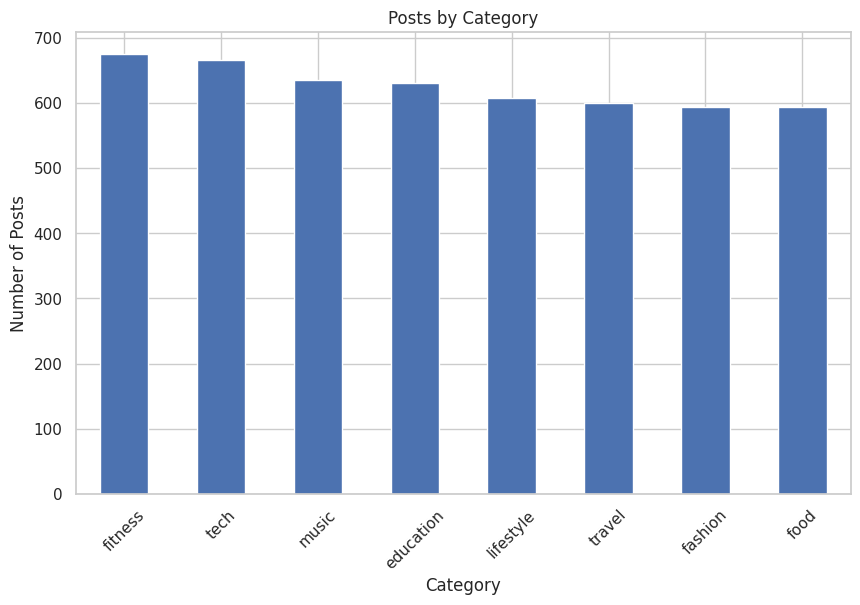

In [ ]:
#Visualization 3 — Posts by Category
category_column = None

for col in ["category", "post_category", "content_category"]:
    if col in b.columns:
        category_column = col
        break

if category_column:

    category_counts = b[category_column].value_counts()

    plt.figure(figsize=(10, 6))

    category_counts.plot(kind="bar")

    plt.xlabel("Category")
    plt.ylabel("Number of Posts")
    plt.title("Posts by Category")

    plt.xticks(rotation=45)
    plt.show()

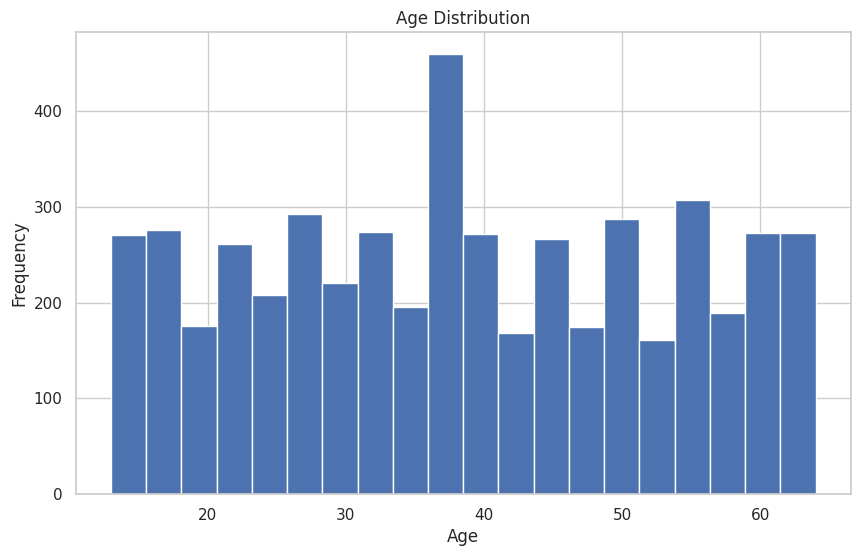

In [ ]:
#Visualization 5 — Age Distribution
if "age" in b.columns:

    plt.figure(figsize=(10, 6))

    plt.hist(
        b["age"],
        bins=20
    )

    plt.xlabel("Age")
    plt.ylabel("Frequency")
    plt.title("Age Distribution")

    plt.show()


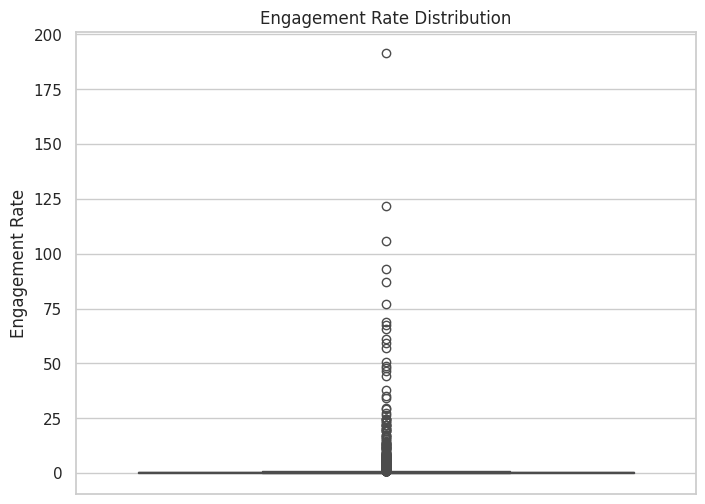

In [ ]:
#Visualization 6 — Engagement Rate Box Plot

rate_column = (
    "engagement_rate"
    if "engagement_rate" in b.columns
    else "engagement_rate_calculated"
)

if rate_column in b.columns:

    plt.figure(figsize=(8, 6))

    sns.boxplot(
        y=b[rate_column]
    )

    plt.ylabel("Engagement Rate")
    plt.title("Engagement Rate Distribution")

    plt.show()



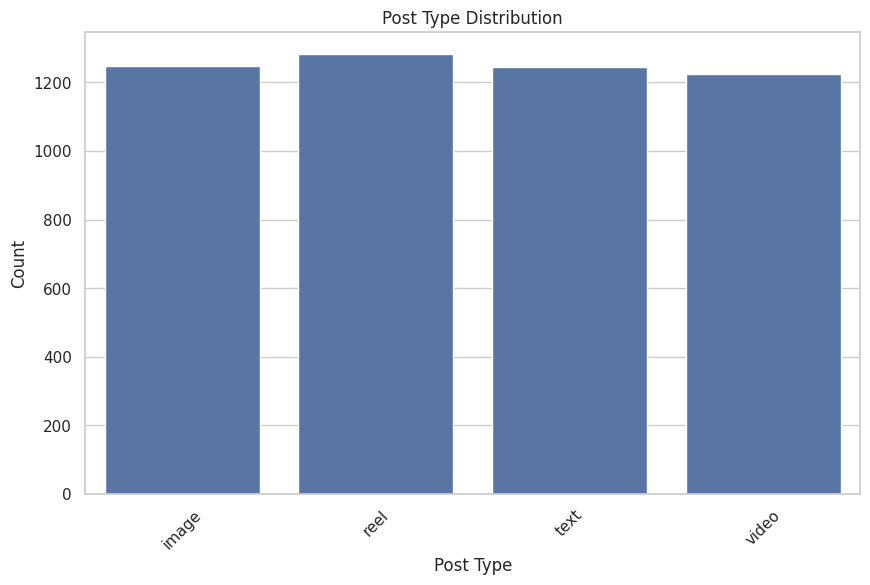

In [ ]:
#Visualization 7 — Count Plot of Post Type

if "post_type" in b.columns:

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=b,
        x="post_type"
    )

    plt.title("Post Type Distribution")
    plt.xlabel("Post Type")
    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.show()

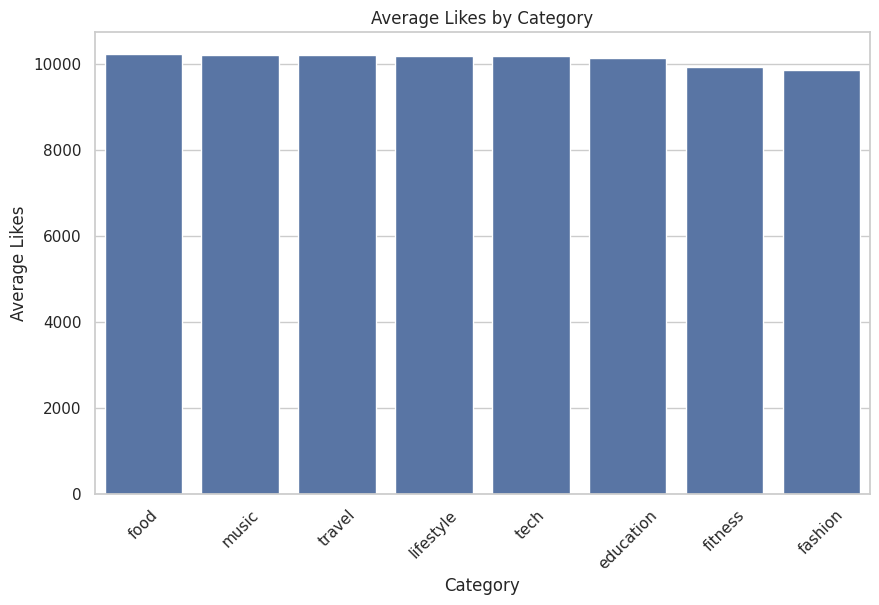

In [ ]:
#Visualization 8 — Average Likes by Category

if category_column and "likes" in b.columns:

    avg_likes_category = (
        b.groupby(category_column)["likes"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=avg_likes_category.index,
        y=avg_likes_category.values
    )

    plt.xlabel("Category")
    plt.ylabel("Average Likes")
    plt.title("Average Likes by Category")

    plt.xticks(rotation=45)

    plt.show()

In [ ]:
#Visualization 9 — Followers vs Sentiment

if "followers" in b.columns and "sentiment" in b.columns:

    plt.figure(figsize=(10, 6))

    sns.violinplot(
        data=b,
        x="sentiment",
        y="followers"
    )

    plt.title("Followers Distribution by Sentiment")
    plt.xlabel("Sentiment")
    plt.ylabel("Followers")

    plt.show()

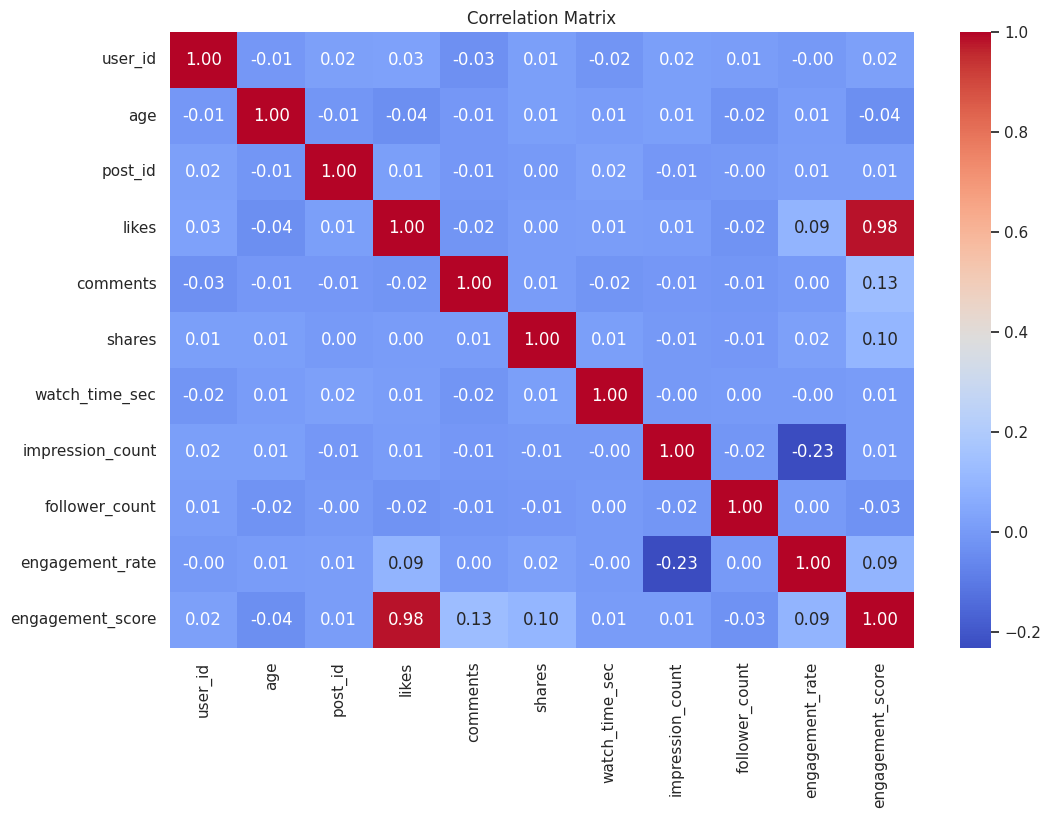

In [ ]:
#Visualization 10 — Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()


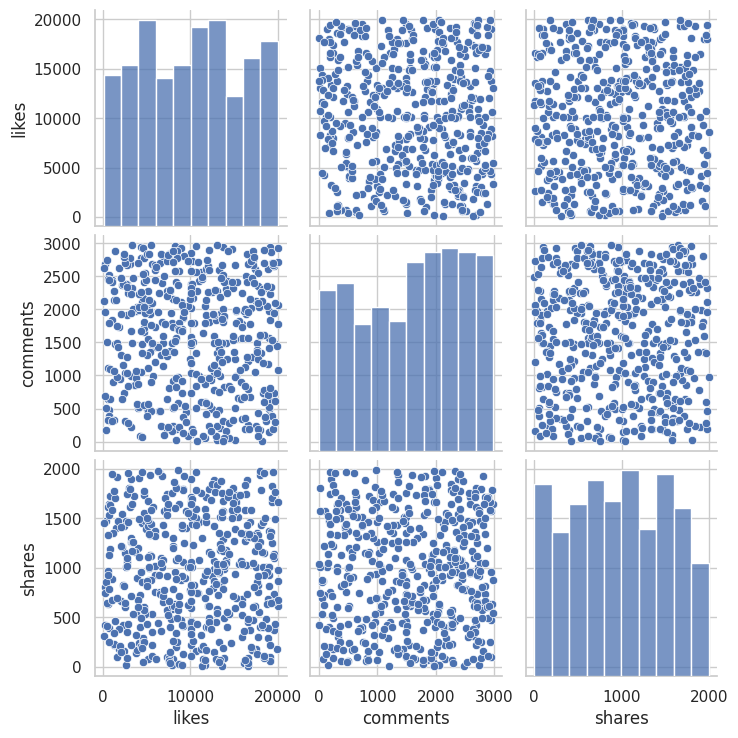

In [ ]:
#Pair plot
pair_columns = [
    col for col in [
        "likes",
        "comments",
        "shares",
        "impressions",
        "watch_time",
        "followers"
    ]
    if col in b.columns
]

if len(pair_columns) >= 2:

    sns.pairplot(
        b[pair_columns].sample(
            min(500, len(b)),
            random_state=42
        )
    )

    plt.show()


In [ ]:
#Swarm Plot — Engagement vs Device
if "device" in b.columns and "engagement_score" in b.columns:

    sample_df = b.sample(
        min(500, len(df)),
        random_state=42
    )

    plt.figure(figsize=(10, 6))

    sns.swarmplot(
        data=sample_df,
        x="device",
        y="engagement_score"
    )

    plt.title("Engagement Score by Device")
    plt.xlabel("Device")
    plt.ylabel("Engagement Score")

    plt.xticks(rotation=45)

    plt.show()



In [ ]:
#Best Performing Post Type
if "post_type" in b.columns and "engagement_score" in b.columns:

    post_type_performance = (
        b.groupby("post_type")["engagement_score"]
        .mean()
        .sort_values(ascending=False)
    )

    print("Average engagement by post type:")
    display(post_type_performance)


Average engagement by post type:


,engagement_score
post_type,
video,12664.594286
image,12649.390537
text,12613.243775
reel,12524.031567


In [ ]:
#Best Performing Category
if category_column and "engagement_score" in b.columns:

    category_performance = (
        b.groupby(category_column)["engagement_score"]
        .mean()
        .sort_values(ascending=False)
    )

    print("Average engagement by category:")
    display(category_performance)



Average engagement by category:


,engagement_score
post_category,
music,12788.549606
food,12739.200675
tech,12686.490226
travel,12650.559167
lifestyle,12639.539539
education,12578.270206
fitness,12457.791852
fashion,12356.420875


In [ ]:
#Countries With Highest Engagement Rate

if "country" in b.columns and rate_column in b.columns:

    country_engagement = (
        b.groupby("country")[rate_column]
        .mean()
        .sort_values(ascending=False)
    )

    display(country_engagement.head(10))


,engagement_rate
country,
brazil,1.540704
australia,1.324339
france,1.146402
uae,1.112352
canada,0.916659
uk,0.850966
japan,0.769623
germany,0.759000
india,0.655005


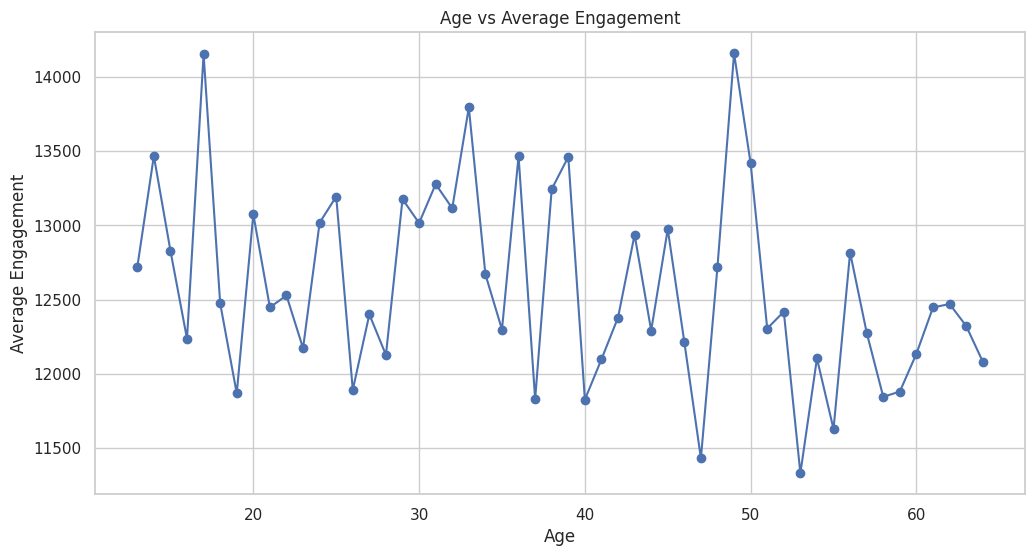

In [ ]:
#Age vs engagement
if "age" in b.columns and "engagement_score" in b.columns:

    age_engagement = (
        b.groupby("age")["engagement_score"]
        .mean()
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        age_engagement.index,
        age_engagement.values,
        marker="o"
    )

    plt.xlabel("Age")
    plt.ylabel("Average Engagement")
    plt.title("Age vs Average Engagement")

    plt.show()

In [ ]:
#Verified vs Non-Verified Accounts
if "verified" in b.columns and "engagement_score" in b.columns:

    verified_analysis = (
        b.groupby("verified")["engagement_score"]
        .agg(["mean", "median", "count"])
    )

    display(verified_analysis)

In [ ]:
#Best Time of Day for Impressions
#creating hour column

if date_column and "impressions" in b.columns:

    b["hour"] = b[date_column].dt.hour

    hourly_impressions = (
        b.groupby("hour")["impressions"]
        .mean()
        .sort_values(ascending=False)
    )

    display(hourly_impressions)

In [ ]:
if date_column and "impressions" in b.columns:

    plt.figure(figsize=(12, 6))

    hourly_impressions.sort_index().plot(
        marker="o"
    )

    plt.xlabel("Hour of Day")
    plt.ylabel("Average Impressions")
    plt.title("Average Impressions by Time of Day")

    plt.show()

In [ ]:
#Device Type Impact on Watch Time
if "device" in b.columns and "watch_time" in b.columns:

    device_watch_time = (
        b.groupby("device")["watch_time"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=False)
    )

    display(device_watch_time)

In [ ]:
#Sentiment Performance
if "sentiment" in b.columns and "engagement_score" in b.columns:

    sentiment_analysis = (
        b.groupby("sentiment")["engagement_score"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=False)
    )

    display(sentiment_analysis)


,mean,median,count
sentiment,,,
negative,12731.498958,12578.5,960
positive,12665.799443,12691.5,2513
neutral,12448.163720,12244.0,1527


In [ ]:
#Negative and Neutral Sentiment Analysis

if "sentiment" in b.columns:

    negative_neutral = b[
        b["sentiment"].isin(["negative", "neutral"])
    ]

    print("Negative and Neutral Sentiment Posts")
    print("Number of posts:", len(negative_neutral))

    if "engagement_score" in negative_neutral.columns:
        display(
            negative_neutral.groupby("sentiment")
            ["engagement_score"]
            .agg(["mean", "median", "count"])
        )

Negative and Neutral Sentiment Posts
Number of posts: 2487


,mean,median,count
sentiment,,,
negative,12731.498958,12578.5,960
neutral,12448.163720,12244.0,1527


In [ ]:
#Interactive Plotly Chart
import plotly.express as px

if date_column and "engagement_score" in b.columns:

    daily_data = (
        b.groupby(date_column)["engagement_score"]
        .sum()
        .reset_index()
    )

    fig = px.line(
        daily_data,
        x=date_column,
        y="engagement_score",
        title="Interactive Daily Engagement Trend"
    )

    fig.show()

In [ ]:
#Automatically Generate Key Findings


print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

# Post type
if "post_type" in b.columns and "engagement_score" in b.columns:
    best_post_type = (
        b.groupby("post_type")["engagement_score"]
        .mean()
        .idxmax()
    )

    best_post_value = (
        b.groupby("post_type")["engagement_score"]
        .mean()
        .max()
    )

    print(
        f"\n1. Highest average engagement post type: "
        f"{best_post_type} ({best_post_value:.2f})"
    )


# Category
if category_column and "engagement_score" in df.columns:

    best_category = (
        b.groupby(category_column)["engagement_score"]
        .mean()
        .idxmax()
    )

    print(
        f"2. Highest average engagement category: "
        f"{best_category}"
    )


# Country
if "country" in b.columns and rate_column in df.columns:

    best_country = (
        b.groupby("country")[rate_column]
        .mean()
        .idxmax()
    )

    print(
        f"3. Country with highest average engagement rate: "
        f"{best_country}"
    )


# Sentiment
if "sentiment" in b.columns and "engagement_score" in b.columns:

    best_sentiment = (
        df.groupby("sentiment")["engagement_score"]
        .mean()
        .idxmax()
    )

    print(
        f"4. Highest performing sentiment: "
        f"{best_sentiment}"
    )


# Device
if "device" in b.columns and "watch_time" in b.columns:

    best_device = (
        b.groupby("device")["watch_time"]
        .mean()
        .idxmax()
    )

    print(
        f"5. Device with highest average watch time: "
        f"{best_device}"
    )




KEY FINDINGS


NameError: name 'b' is not defined

In [ ]:
#One-Page Summary
print("=" * 70)
print("SOCIAL MEDIA ENGAGEMENT ANALYTICS – FINAL SUMMARY")
print("=" * 70)

print(f"""
Dataset contains {b.shape[0]} records and {b.shape[1]} columns.

DATA CLEANING
-------------
Missing values were identified and handled using appropriate
imputation techniques. Duplicate records were removed and
categorical/text fields were standardized.

CONTENT PERFORMANCE
-------------------
Post types and content categories were compared using average
engagement scores.

USER TRENDS
-----------
Age, verification status and country-level engagement were
analysed to understand differences in user behaviour.

BEHAVIOURAL INSIGHTS
--------------------
Impressions were analysed by time of day and watch time was
compared across device types.

SENTIMENT ANALYSIS
------------------
Positive, neutral and negative posts were compared based on
engagement metrics to identify differences in performance.

STATISTICAL ANALYSIS
--------------------
Mean, median, mode, standard deviation, variance and
percentiles were calculated for the major engagement metrics.

VISUAL ANALYSIS
---------------
Multiple Matplotlib and Seaborn visualizations were created,
including scatter plots, line charts, bar charts, pie charts,
histograms, box plots, violin plots and correlation heatmaps.

CONCLUSION
----------
The analysis provides an evidence-based view of social media
engagement patterns and can be used to understand content
performance, user behaviour and engagement trends.
""")



SOCIAL MEDIA ENGAGEMENT ANALYTICS – FINAL SUMMARY


NameError: name 'df' is not defined